# MULTIMODAL RAG Pipeline
### PDF → Unstructured (Text + Images + Tables) → FAISS → Cross-Modal Query → Answer

In [ ]:
!pip install langchain langchain-community langchain-openai faiss-cpu unstructured[all-docs] pillow python-dotenv -q

In [35]:
import os
import uuid
import base64
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.documents import Document
from unstructured.partition.pdf import partition_pdf

load_dotenv("E:/ACADEMY CLASS NOTEBOOKS/.env")

True

## Step 1: Parse PDF with Unstructured (Extract Text, Images & Tables)

In [36]:
pdf_path = "E:/ACADEMY CLASS NOTEBOOKS/RAG/Notebooks/Transformer Architecture.pdf"
image_output_dir = "extracted_images"
os.makedirs(image_output_dir, exist_ok=True)

elements = partition_pdf(
    filename=pdf_path,
    strategy="hi_res",
    extract_images_in_pdf=True,
    extract_image_block_output_dir=image_output_dir,
    infer_table_structure=True
)

print(f"Total Elements Extracted: {len(elements)}")

Total Elements Extracted: 173


## Step 2: Categorize Elements by Type

In [37]:
texts = []
tables = []
images = []

for element in elements:
    element_type = type(element).__name__
    if element_type == "Table":
        tables.append(str(element))
    elif element_type == "Image":
        images.append(str(element))
    else:
        texts.append(str(element))

print(f"Text Elements: {len(texts)}")
print(f"Table Elements: {len(tables)}")
print(f"Image Elements: {len(images)}")

Text Elements: 167
Table Elements: 4
Image Elements: 2


## Step 3: Summarize Images & Tables using LLM

In [38]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def summarize_element(element_text, element_type):
    prompt = f"""Summarize the following {element_type} concisely for retrieval purposes:

{element_text}

Summary:"""
    response = llm.invoke(prompt)
    return response.content

table_summaries = [summarize_element(t, "table") for t in tables]
image_summaries = [summarize_element(img, "image description") for img in images]

print(f"Table Summaries Generated: {len(table_summaries)}")
print(f"Image Summaries Generated: {len(image_summaries)}")

Table Summaries Generated: 4
Image Summaries Generated: 2


## Step 4: Create Documents for All Modalities

In [39]:
documents = []

image_files = sorted(Path(image_output_dir).glob("*.jpg"))

for text in texts:
    if text.strip():
        documents.append(Document(
            page_content=text,
            metadata={"type": "text"}
        ))

for i, (table, summary) in enumerate(zip(tables, table_summaries)):
    documents.append(Document(
        page_content=summary,
        metadata={"type": "table", "original": table}
    ))

for i, (img, summary) in enumerate(zip(images, image_summaries)):
    img_path = str(image_files[i]) if i < len(image_files) else None
    documents.append(Document(
        page_content=summary,
        metadata={"type": "image", "original": img, "image_path": img_path}
    ))

print(f"Total Documents: {len(documents)}")
for doc_type in ["text", "table", "image"]:
    count = sum(1 for d in documents if d.metadata["type"] == doc_type)
    print(f"  {doc_type}: {count}")

Total Documents: 173
  text: 167
  table: 4
  image: 2


## Step 5: Create Embeddings & Store in FAISS (Shared Embedding Space)

In [40]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Create separate vector stores per modality for balanced retrieval
text_docs = [d for d in documents if d.metadata["type"] == "text"]
table_docs = [d for d in documents if d.metadata["type"] == "table"]
image_docs = [d for d in documents if d.metadata["type"] == "image"]

text_store = FAISS.from_documents(text_docs, embeddings)
table_store = FAISS.from_documents(table_docs, embeddings)
image_store = FAISS.from_documents(image_docs, embeddings)

print(f"Text Store: {text_store.index.ntotal} vectors")
print(f"Table Store: {table_store.index.ntotal} vectors")
print(f"Image Store: {image_store.index.ntotal} vectors")

Text Store: 167 vectors
Table Store: 4 vectors
Image Store: 2 vectors


## Step 6: Create Retriever (Cross-Modal Search)

In [41]:
# Retrieve top results from each modality separately
text_retriever = text_store.as_retriever(search_kwargs={"k": 3})
table_retriever = table_store.as_retriever(search_kwargs={"k": 2})
image_retriever = image_store.as_retriever(search_kwargs={"k": 2})

## Step 7: Query with Multimodal Context

## Answer

The encoder of the Transformer architecture consists of a stack of identical layers, each containing two main components: multi-head self-attention and a feed-forward neural network. 

1. **Multi-Head Self-Attention**: This mechanism allows the encoder to weigh the importance of different words in the input sequence when encoding a particular word. It computes attention scores using scaled dot-product attention, which helps the model focus on relevant parts of the input.

2. **Feed-Forward Neural Network**: After the self-attention layer, the output is passed through a feed-forward neural network, which is applied independently to each position. This network consists of two linear transformations with a ReLU activation in between.

3. **Add & Norm**: Each of the two main components (self-attention and feed-forward) is followed by a residual connection and layer normalization. This helps stabilize and improve the training of the model.

4. **Positional Encoding**: Since the Transformer does not have a built-in notion of word order (unlike RNNs), positional encodings are added to the input embeddings to provide information about the position of each word in the sequence.

The encoder processes the input sequence and generates a set of continuous representations that capture the contextual relationships between words, which are then passed to the decoder for generating output sequences.

---
## Retrieved Sources

### Source 1 [TEXT]

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.


### Source 2 [TEXT]

...

### Source 4 [TABLE]

BLEU Training Cost (FLOPs) Model EN-DE EN-FR EN-DE EN-FR ByteNet [18] 23.75 Deep-Att + PosUnk [39] 39.2 1.0 - 107° GNMT + RL [38] 246 39.92 2.3-10!9 1.4. 102 ConvS2S [9] 25.16 40.46 96-10!% 1.5-107° MoE [32] 26.03 40.56 2.0-10'% 1.2-107° Deep-Att + PosUnk Ensemble [39] 40.4 8.0 - 107° GNMT + RL Ensemble [38] 26.30 41.16 1.8-1029 1.1.10?! ConvS2S Ensemble [9] 26.36 41.29 7.7-10!9 1.2.10?! Transformer (base model) 27.3 38.1 3.3- 1018 Transformer (big) 28.4 41.8 2.3 - 1019


### Source 5 [TABLE]

"Parser Training WSJ 23 F1 Vinyals & Kaiser el al. (2014) [37] | WSJ only, discriminative 88.3 Petrov et al. (2006) [29] WSJ only, discriminative 90.4 Zhu et al. (2013) [40] WSJ only, discriminative 90.4 Dyer et al. (2016) [8] Transformer (4 layers) , discriminative 91.7 , discriminative Zhu et al. (2013) [40] semi-supervised 91.3 Huang & Harper (2009) [14] semi-supervised 91.3 McClosky et al. (2006) [26] semi-supervised 92.1 semi-supervised 92.1 semi-supervised . multi-task 93.0 generative 93.3 Vinyals & Kaiser el al. (2014) [37] Transformer (4 layers) Luong et al. (2015) [23] Dyer et al. (2016) [8]"


### Source 6 [IMAGE]

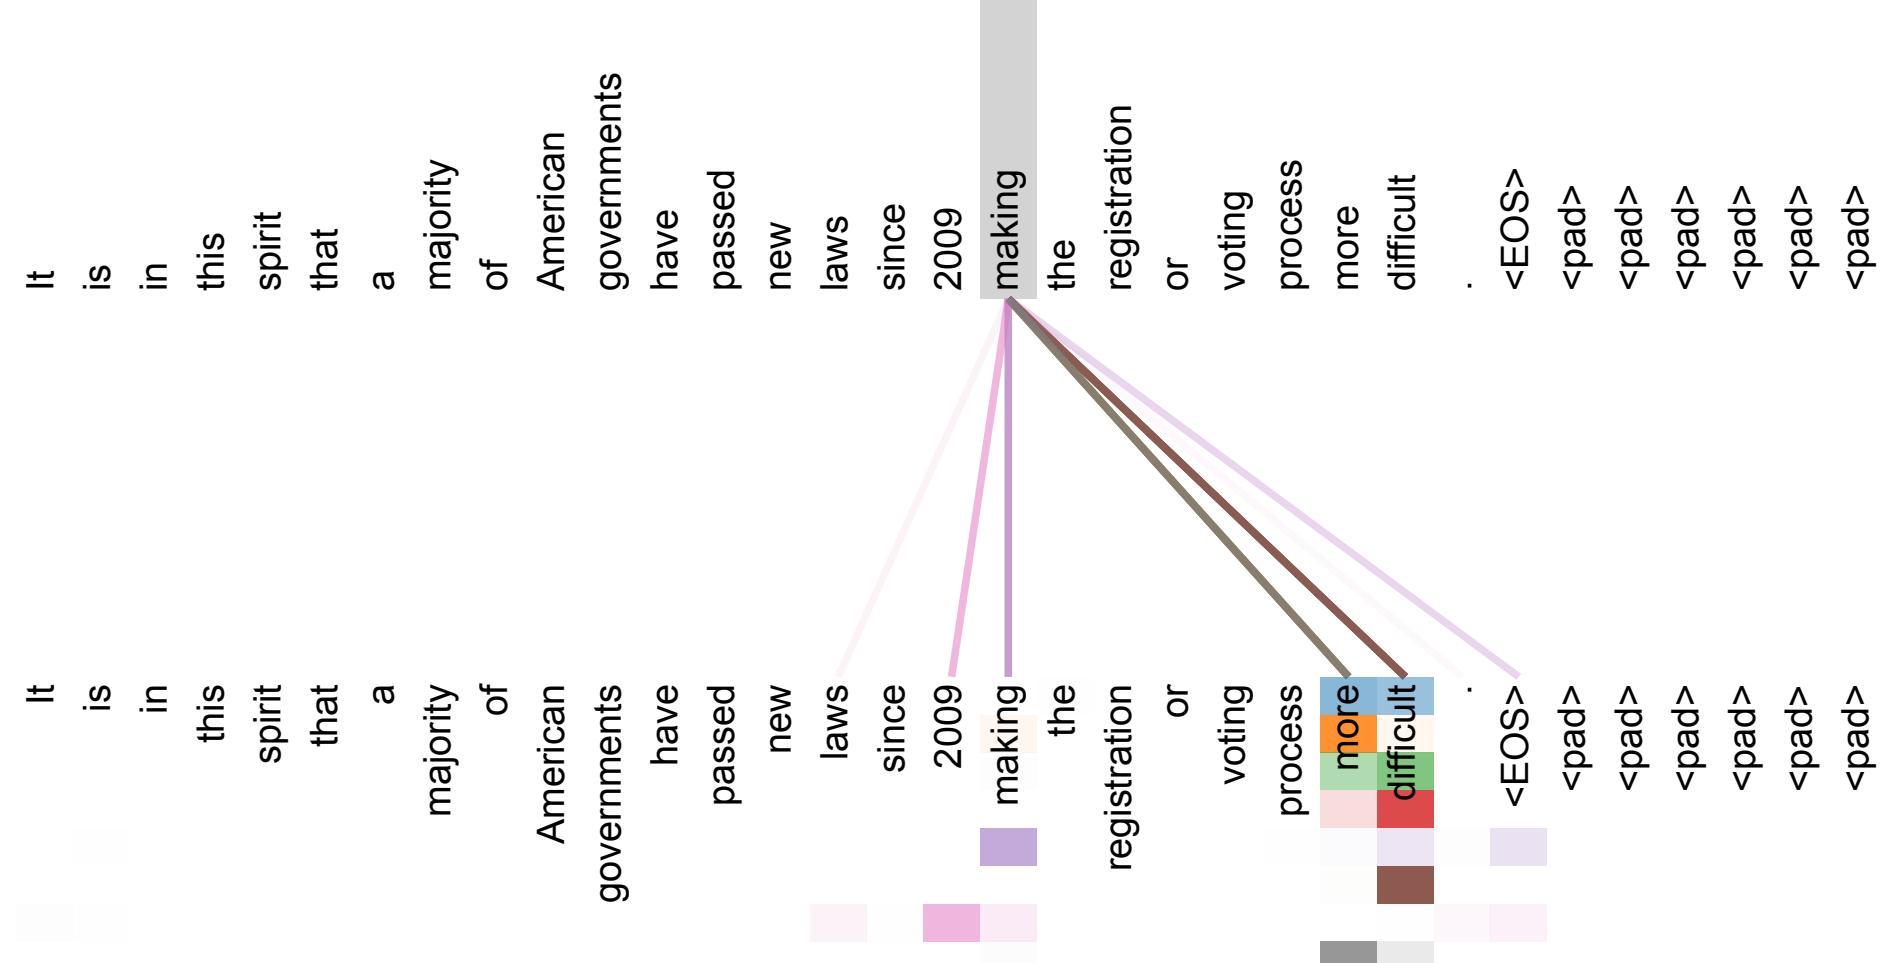

*Description: Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Add & Norm Feed Attention Forward , Nx Add & Norm Nx | --Casd a Nom] Add & Norm Masked Multi- Head Multi-Head Attention Attention Se ae, Se a, Positional Positional Encoding @ ? 0 @ Encoding Input Output Embedding Embedding Inputs Outputs (*

### Source 7 [IMAGE]

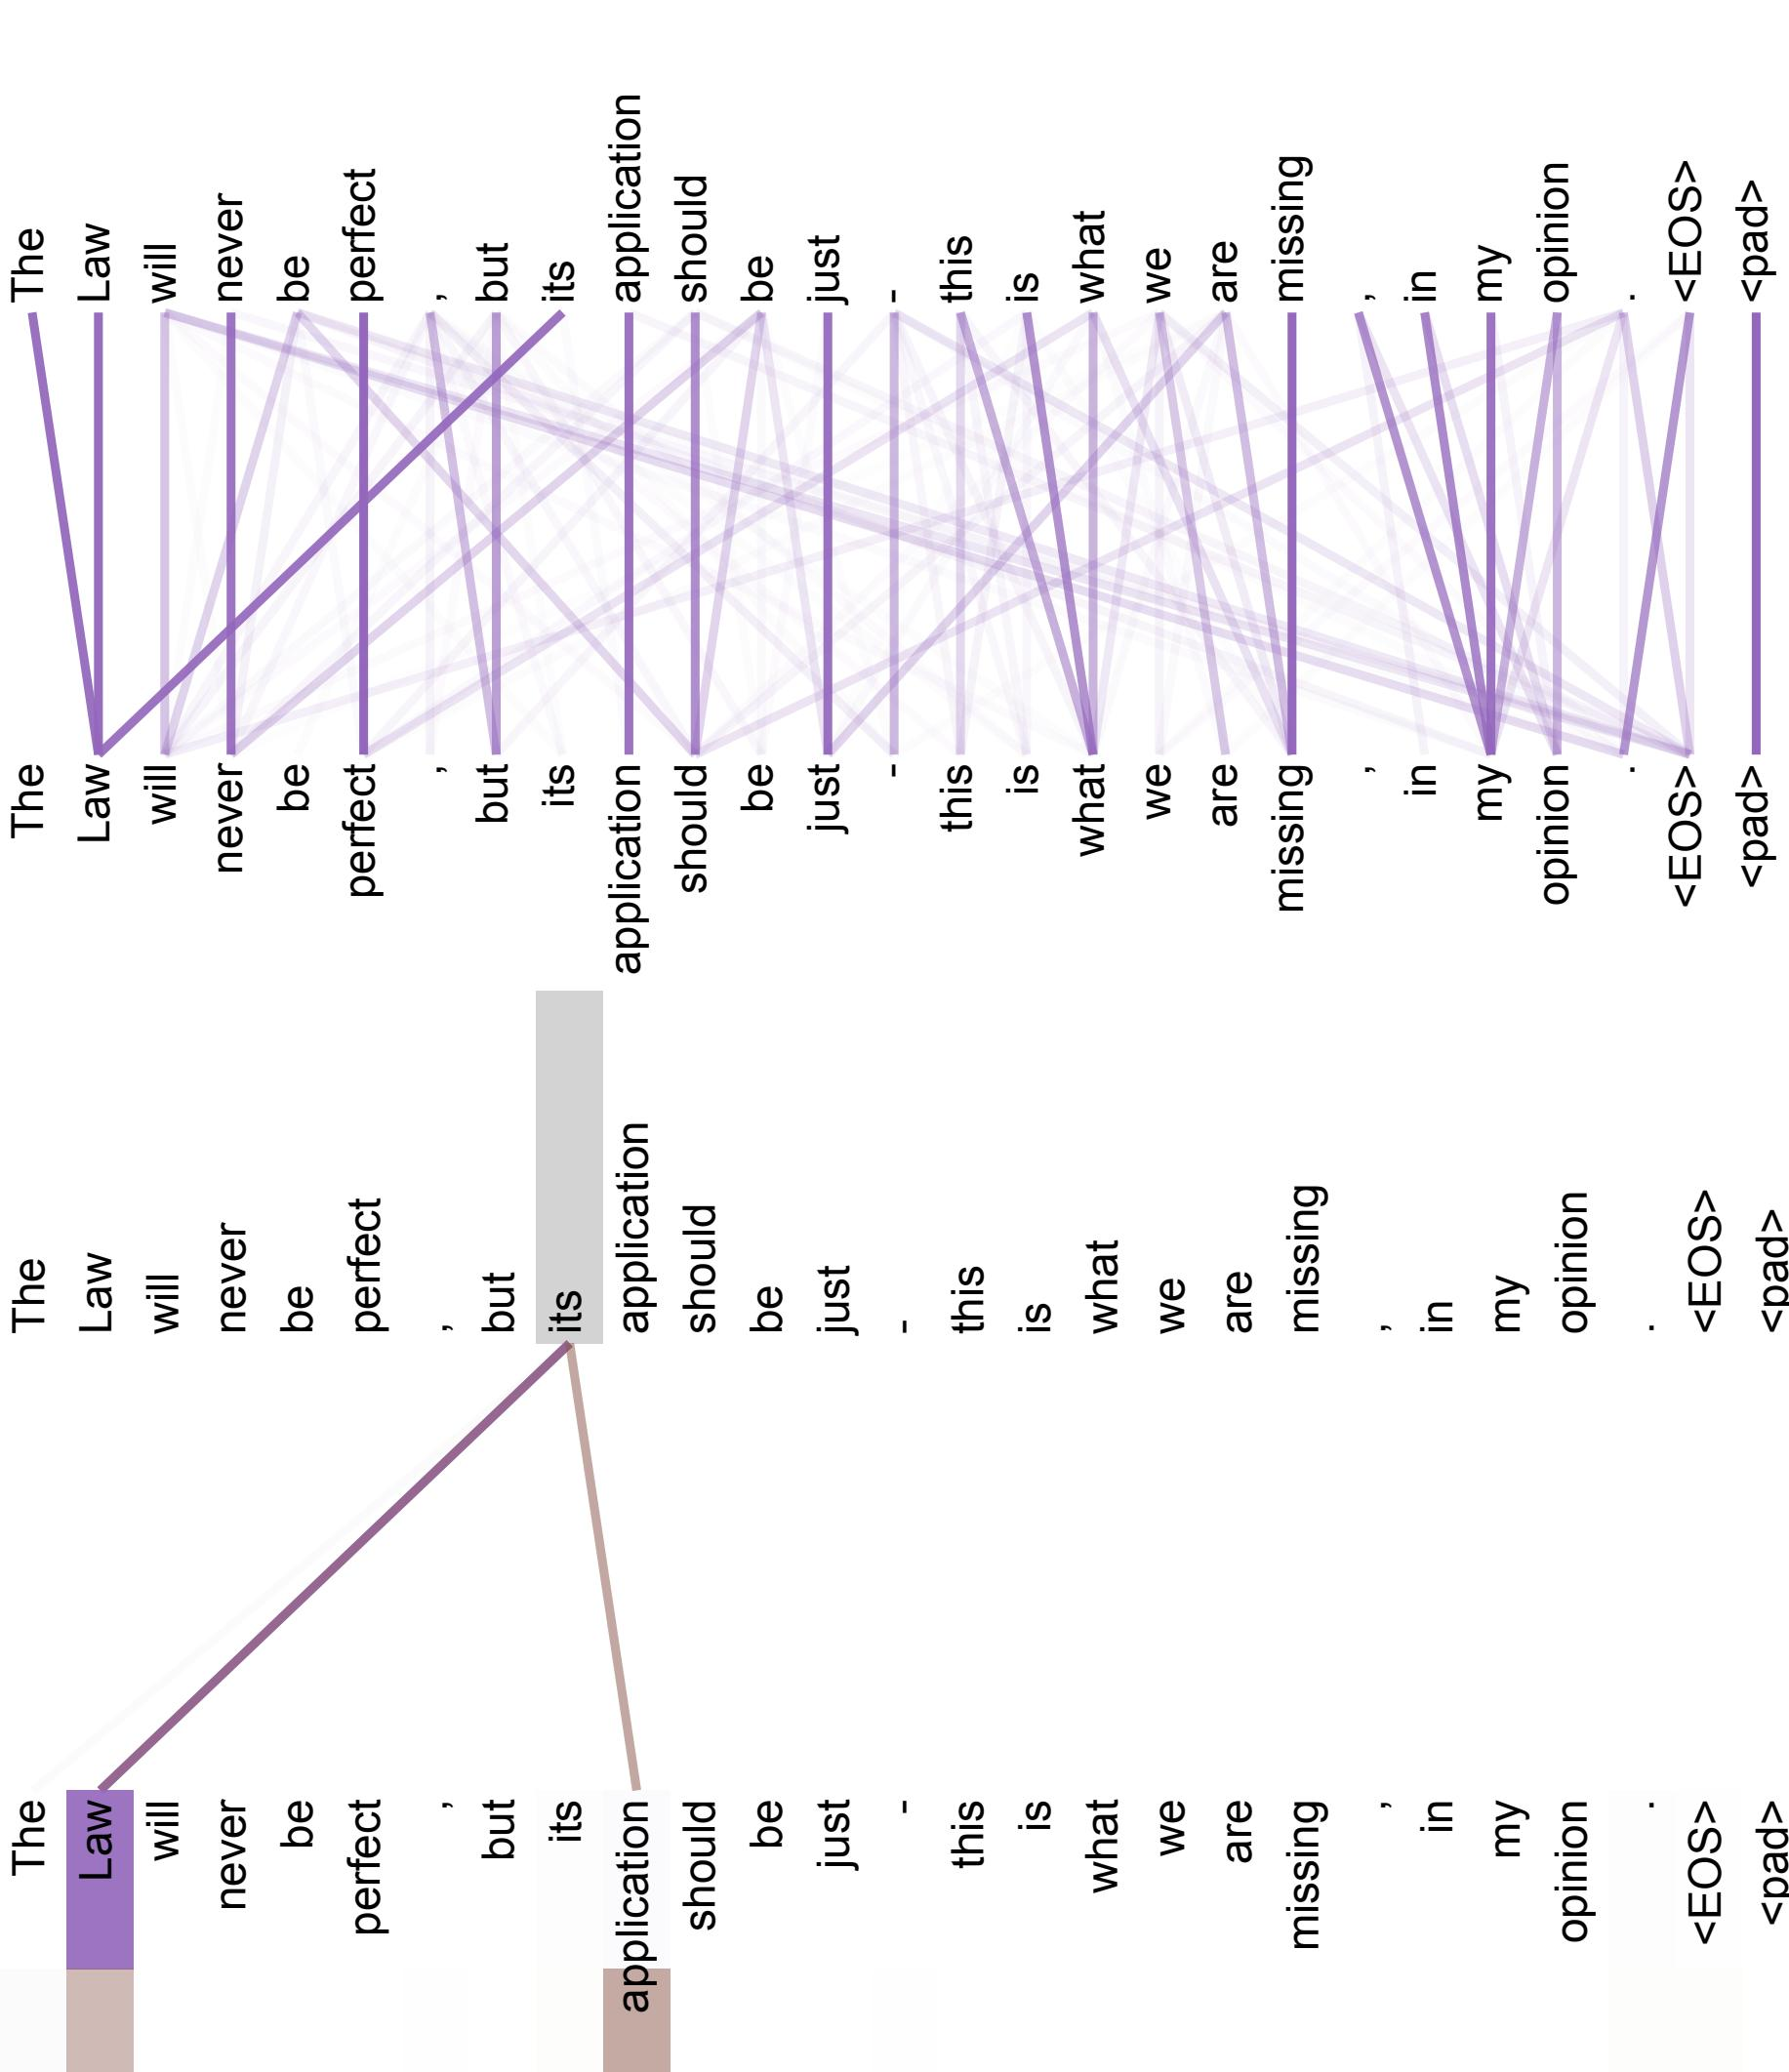

*Description: Scaled Dot-Product Attention Multi-Head Attention Scaled Dot-Product Attention v*

In [44]:
from IPython.display import display, Image, HTML, Markdown

query = "Explain encoder of the transformer"

# Retrieve from all three modalities
text_results = text_retriever.invoke(query)
table_results = table_retriever.invoke(query)
image_results = image_retriever.invoke(query)

retrieved_docs = text_results + table_results + image_results

# Build context for LLM
context_parts = []
for doc in retrieved_docs:
    doc_type = doc.metadata["type"]
    if doc_type == "table":
        context_parts.append(f"[TABLE]\n{doc.metadata['original']}")
    elif doc_type == "image":
        context_parts.append(f"[IMAGE DESCRIPTION]\n{doc.metadata['original']}")
    else:
        context_parts.append(f"[TEXT]\n{doc.page_content}")

context = "\n\n".join(context_parts)

prompt = f"""Answer the question based only on the following multimodal context (text, tables, and image descriptions):

{context}

Question: {query}
Answer:"""

response = llm.invoke(prompt)

# Display the LLM answer
display(Markdown(f"## Answer\n\n{response.content}"))

# Display retrieved sources with actual images and tables
display(Markdown("---\n## Retrieved Sources"))

for i, doc in enumerate(retrieved_docs):
    doc_type = doc.metadata["type"]
    display(Markdown(f"### Source {i+1} [{doc_type.upper()}]"))

    if doc_type == "table":
        display(HTML(f"<table style='border:1px solid #ccc; padding:8px;'><tr><td><pre>{doc.metadata['original']}</pre></td></tr></table>"))

    elif doc_type == "image":
        img_path = doc.metadata.get("image_path")
        if img_path and os.path.exists(img_path):
            display(Image(filename=img_path, width=500))
        display(Markdown(f"*Description: {doc.metadata['original'][:300]}*"))

    else:
        print(doc.page_content[:500])

## Retrieved Source Elements

In [43]:
for i, doc in enumerate(retrieved_docs):
    print(f"\n--- Result {i+1} [{doc.metadata['type'].upper()}] ---")
    print(doc.page_content[:300])


--- Result 1 [TEXT] ---
Figure 1: The Transformer - model architecture.

--- Result 2 [TEXT] ---
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.

--- Result 3 [TEXT] ---
In this work we propose the Transformer, a model architecture eschewing recurrence and instead relying entirely on an attention mechanism to draw global dependencies between input and output. The Transformer allows for significantly more parallelization and can reach a new state of the art in transl

--- Result 4 [TABLE] ---
The table presents various training configurations for a model, detailing parameters such as PPL (Perplexity), BLEU score, number of parameters, and other hyperparameters. Key configurations include:

- **Base Model**: 6 layers, 512 hidden units, 2048 feedforward units, 8 attention heads, 64 batch s

--- Result 5 [TABLE] ---
The table

## Test Questions

1. What is the architecture of the Transformer model?
2. What are the key results shown in the tables?
3. How does multi-head attention work?
4. What training data was used?
5. How does the Transformer compare to other models in BLEU score?